**Tugas Clustering**

**Nama : Ken Foster Morintoh**\
\
**NIM : 672020175**

Sebuah department store ingin menganalisa kelompok perilaku belanja dari pelanggannya, dengandata set yang diberikan buatlah analisa:\
a. Gunakan kolom ke 2 hingga 4 sebagai input features\
b. Dengan metode elbow, analisa jumlah cluster yang tepat\
c. Gunakan K-Means clustering dan analisa hasilnya

Sebuah department store ingin menganalisa kelompok perilaku belanja dari pelanggannya, dengandata set yang diberikan buatlah analisa:\
a. Gunakan kolom ke 2 hingga 4 sebagai input features\
b. Dengan metode elbow, analisa jumlah cluster yang tepat\
c. Gunakan K-Means clustering dan analisa hasilnya\
d. Bandingkan hasilnya dengan menggunakan metode K-Mean


**Kesimpulan:**



 Dari hasil analisis yang saya lakukan yaitu clustering dengan kmeans dan clustering dengan hierarikal adalah dibawah ini sebagai berikut :\

 Dari data dengan 200 sample, terdiri dari 3 fitur yang ada diatantaranya usia , rating, dan pendapatan dengan menggunakan visualisasi 3D.

**Clustering dengan K-means**

**cluster yang baik adalah 6 berdasarkan metode elbow pada k-mean dan didukung dengan metode silhoutte score**


 -> Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru)\
adapun Ratting tertinggi(60 - 100)  diberikan constumer yang umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
-> Rating terendah 0 - 40 diberikan usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
-> Rating 40 - 60 diberikan customer pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)
pada cluster ini terbnyak dari dari keseluruhan data.



**Clustering dengan Hierarchy** 

walaupun dalam model ini kita bebas menetukan jumlah k-nya kita juga harus melihat struktur dendogram untuk mlihat berapa jumlah kluster yang optimal.\
disini saya tidak menarik gari potong dengan jarak euclidiannya <150.\
jadi , **jumlah cluster yang optimal adalah 6 cluster berdasarkan dendogram (garis potong <150)**



 -> Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru) \
adapun Ratting tertinggi(60 - 100)  diberikan constumer yang umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
-> Rating terendah 0 - 40 diberikan usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
-> Rating 40 - 60 diberikan customer pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)
pada cluster ini terbnyak dari dari keseluruhan data.

->Cluster 1 - 4 menunjukan adanya kemiripan(tergabung) pada jarak euclidian yang lebih besar.\

-> Begitupun cluster 5 dan 6 yang punya kemiripan(tergabung) dalam jarak euclidian yang lebih besar(lebih besar dibanding cluster 1- 4)

**perbandingan Kedua Model Clustering**

**dari analisis klustering dengan kedua model dibawah ini, keduanya memberikan hasil yang sangat mirip.**

Namun Perbedaan yang signifikan dari keduanya adalah di penyajian representasi visual dari struktur data dalam menentukan jumlah cluster. Pada hirarchy clustering kita mendapatkan dendogram struktur tree yang dapat menunjukan dimana jarak mereka digabungkan sendangkan K-mean tidak memberikan hubungan dari kesuluruhan data dimana jarak mereka tergabung.


In [95]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt


In [96]:
dataset = pd.read_csv('Customer.csv')

In [97]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
0,1,Perempuan,23,87,29
1,2,Laki,60,4,30
2,3,Perempuan,21,73,30
3,4,Laki,53,4,33
4,5,Laki,18,92,33
...,...,...,...,...,...
195,196,Laki,28,75,87
196,197,Laki,36,10,87
197,198,Laki,36,92,87
198,199,Perempuan,52,13,88


In [98]:
dataset.describe()

,IDPelanggan,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,50.200000,60.560000
std,57.879185,13.969007,25.823522,26.264721
min,1.000000,18.000000,1.000000,15.000000
25%,50.750000,28.750000,34.750000,41.500000
50%,100.500000,36.000000,50.000000,61.500000
75%,150.250000,49.000000,73.000000,78.000000
max,200.000000,70.000000,99.000000,137.000000


In [99]:
dataset['Kelamin'] = dataset.Kelamin.str.replace('Perempuan','0')
dataset['Kelamin'] = dataset.Kelamin.str.replace('Laki','1')


In [100]:
dataset.corr()

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
IDPelanggan,1.000000,0.075370,-0.041300,0.011165,0.875266
Kelamin,0.075370,1.000000,0.060867,-0.058109,0.056410
Usia,-0.041300,0.060867,1.000000,-0.327227,-0.012398
Rating_belanja (1-100),0.011165,-0.058109,-0.327227,1.000000,0.009903
Pendapatan (juta Rp),0.875266,0.056410,-0.012398,0.009903,1.000000


In [101]:
dataset.isnull().sum()

IDPelanggan               0
Kelamin                   0
Usia                      0
Rating_belanja (1-100)    0
Pendapatan (juta Rp)      0
dtype: int64

In [102]:
dataset.dtypes

IDPelanggan                int64
Kelamin                   object
Usia                       int64
Rating_belanja (1-100)     int64
Pendapatan (juta Rp)       int64
dtype: object

In [103]:
dataset_noid= dataset.drop(columns=['IDPelanggan', 'Kelamin'])

dataset_noid



,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
0,23,87,29
1,60,4,30
2,21,73,30
3,53,4,33
4,18,92,33
...,...,...,...
195,28,75,87
196,36,10,87
197,36,92,87
198,52,13,88


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# Mengimpor dataset
dataset = pd.read_csv('Customer.csv')
X = dataset.iloc[:, [2,3,4]].values

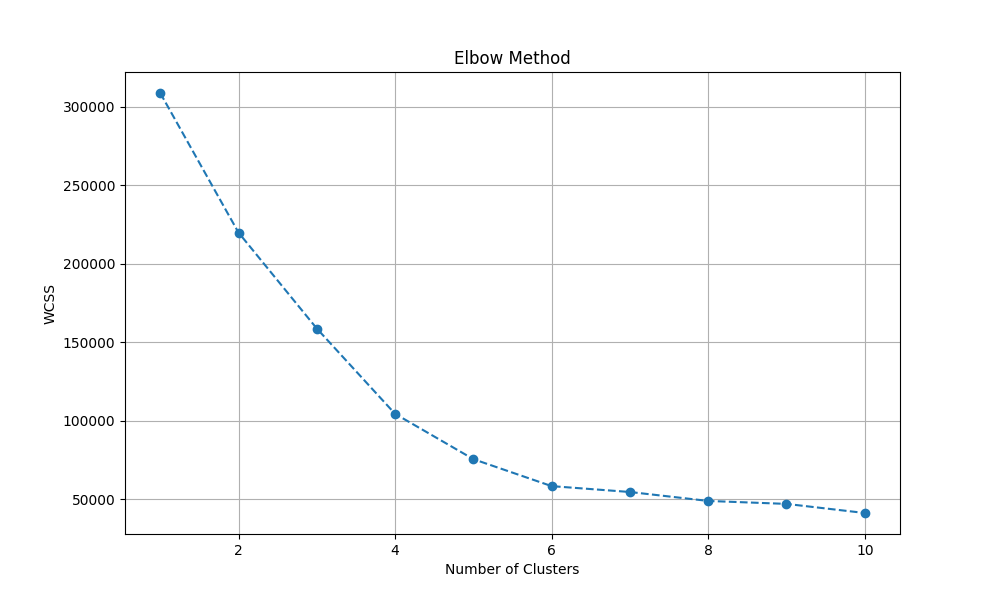

In [105]:

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Reatif tidak mudah menentukan jumlah optimal K pada beberapak kasus tertentu. Dsini saya memilih 6 sebagai k-optimal berdasarkan plot yang ada menggunakan k-means\
namun Kerena plotnya masih melambai kurang merepresenstasikan siku(elbow). \




**untuk memastikan membuktikan 6 adalah cluster yang tepat saya melakukan analisis silhoutee**

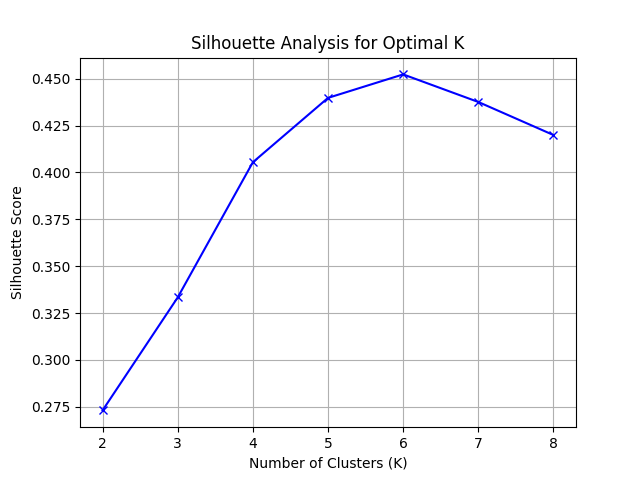

In [114]:

from sklearn.metrics import silhouette_score

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []

for num_clusters in range_n_clusters:
    # K-means
    kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42)
    kmeans.fit(dataset_noid)
    cluster_labels = kmeans.labels_
    
    # silhouette score
    silhouette_avg.append(silhouette_score(dataset_noid, cluster_labels))


plt.figure()
plt.plot(range_n_clusters, silhouette_avg, 'bx-')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal K')
plt.grid(True)
plt.show()

Berdasarkan plot diatas makin membuktikan pilihan kita bahwa 6 adalah jumlah K yang optimal adalah paling tepat. 

In [107]:
X.shape

(200, 3)

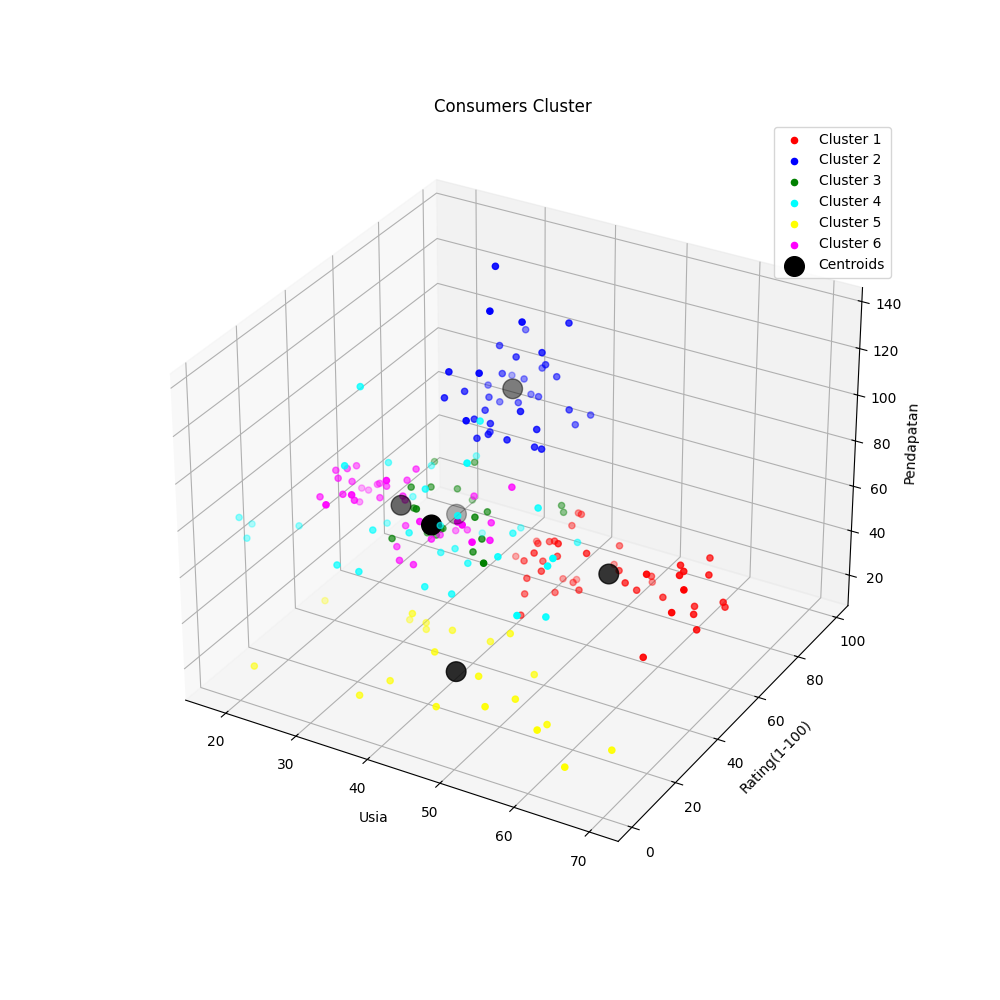

In [108]:
from mpl_toolkits.mplot3d import Axes3D


%matplotlib widget 
# Proses K-Means Clustering
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
# Visualisasi hasil clusters

ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],  X[y_kmeans == 0,2],c = 'red', label = 'Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1,2],c = 'blue', label = 'Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2,2],c = 'green', label = 'Cluster 3')
ax.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], X[y_kmeans == 3,2] ,c = 'cyan', label = 'Cluster 4')
ax.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], X[y_kmeans == 4,2] ,c = 'yellow', label = 'Cluster 5')
ax.scatter(X[y_kmeans == 5, 0], X[y_kmeans == 5, 1], X[y_kmeans == 5,2] ,c = 'magenta', label = 'Cluster 6')

#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', label='Centroids')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='black', label='Centroids')
ax.set_title('Consumers Cluster')
ax.set_xlabel('Usia')
ax.set_ylabel('Rating(1-100)')
ax.set_zlabel('Pendapatan')
ax.legend()

plt.show()

**1. Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru) \
adapun Ratting tertinggi(60 - 100)  didpatkan  didapakan berdasarkan umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
2. Rating terendah 0 - 40 pada usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
3. Rating 40 - 60 diperoleh pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)**

**Berikutnya adalah Clustering dengan Hierarky**

disini saya menggunakan algomertive (cluster bottom to up)





C:\Users\knmor\AppData\Local\Temp\ipykernel_10728\3814685644.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 8))


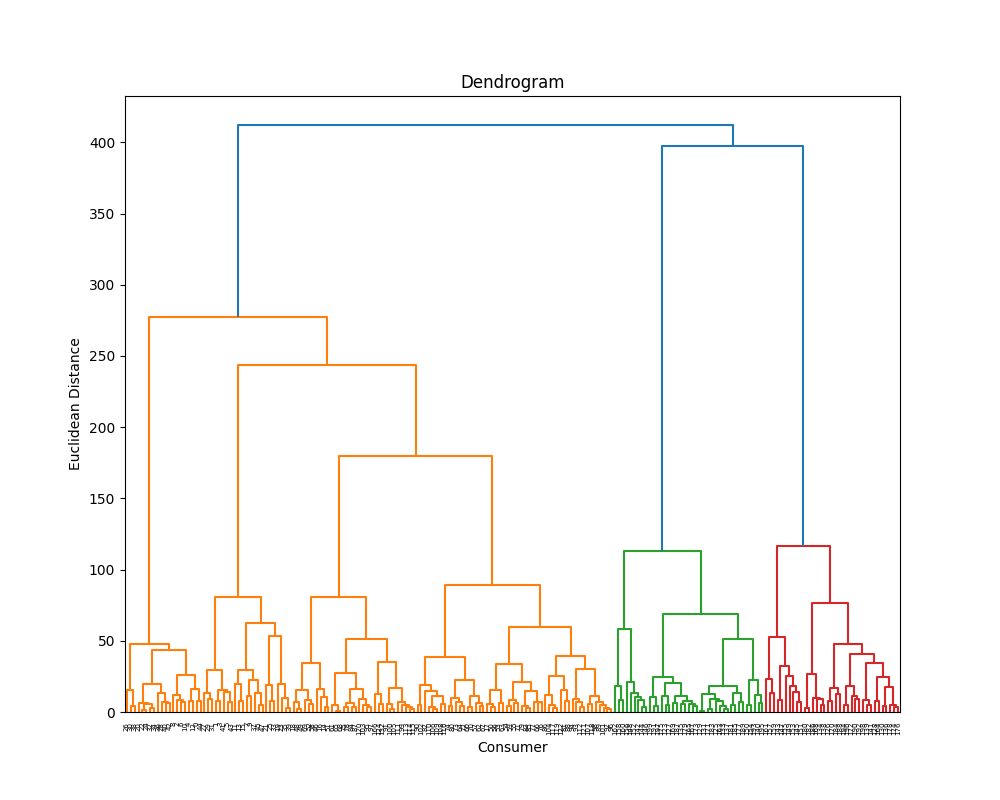

In [109]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 8))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

plt.title('Dendrogram')
plt.xlabel('Consumer')
plt.ylabel('Euclidean Distance', rotation = 90)
plt.show()

Berdasarkan dendoogram diatas cukup jelas bahwa cluster yang baik dipilih adalah 6. 

saya mengambil garis potong (jarak euclidian) dari <150 
cluster 1, 2, 3, dan 4 (hijau) dimana cenderung punya kemiripan.
Cluster 5 dan cluster 6 punya kemripan. 


In [110]:
from sklearn.cluster import AgglomerativeClustering

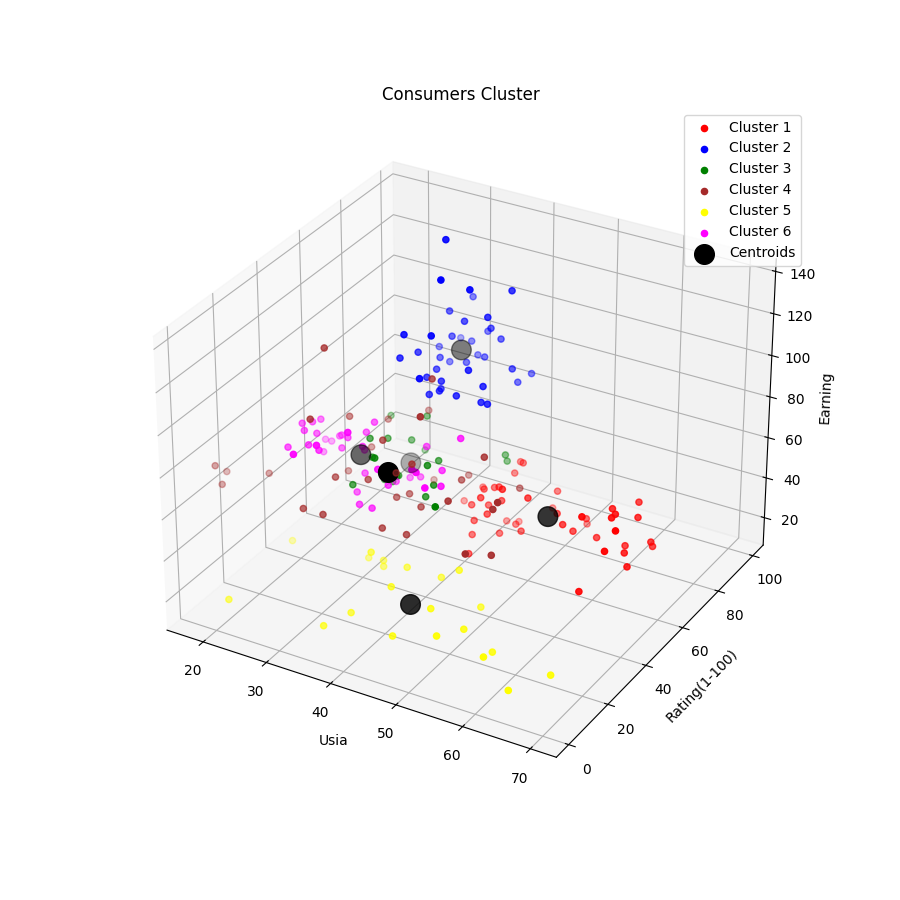

In [113]:
# Menjalankan Hierarchical Clustering ke dataset

from mpl_toolkits.mplot3d import Axes3D

hc = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)


fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

# Visualisasi hasil clusters
ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],  X[y_kmeans == 0,2],c = 'red', label = 'Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1,2],c = 'blue', label = 'Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2,2],c = 'green', label = 'Cluster 3')
ax.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], X[y_kmeans == 3,2] ,c = 'brown', label = 'Cluster 4')
ax.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], X[y_kmeans == 4,2] ,c = 'yellow', label = 'Cluster 5')
ax.scatter(X[y_kmeans == 5, 0], X[y_kmeans == 5, 1], X[y_kmeans == 5,2] ,c = 'magenta', label = 'Cluster 6')

#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', label='Centroids')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='black', label='Centroids')
ax.set_title('Consumers Cluster')
ax.set_xlabel('Usia')
ax.set_ylabel('Rating(1-100)')
ax.set_zlabel('Earning')
ax.legend()

plt.show()

 -> Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru) \
adapun Ratting tertinggi(60 - 100)  diberikan constumer yang umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
-> Rating terendah 0 - 40 diberikan usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
-> Rating 40 - 60 diberikan customer pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)
pada cluster ini terbnyak dari dari keseluruhan data.

Sudah sangat mirip dengan klustering k-means yang aritnya clustering berhasil dilakukan dengan baik.\

**Kesimpulan terlampir pada cell 2**